In [ ]:
# Install required libraries
!pip install pandas numpy scikit-learn matplotlib seaborn plotly xgboost lightgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# 1. DATA LOADING AND PREPARATION
# ============================================================================

def load_and_clean_data(capital_file, asset_file, profitability_file, performance_file):
    """
    Load and clean the banking datasets
    """
    # Load Capital Adequacy data
    capital_df = pd.read_excel(capital_file, sheet_name='Capital Adequacy', skiprows=2)

    # Load Asset Quality data
    asset_df = pd.read_excel(asset_file, sheet_name='Asset Quality', skiprows=2)

    # Load Profitability data
    profit_df = pd.read_excel(profitability_file, sheet_name='Profitability', skiprows=2)

    # Load Performance Indicators
    performance_df = pd.read_excel(performance_file, sheet_name='Performance Indicators', skiprows=2)

    return capital_df, asset_df, profit_df, performance_df

# Load your uploaded file
# Replace with your actual file path
file_path = 'your_file.xlsx'

# For the PDF data, you'll need to structure it into a DataFrame
# Based on the CAMEL framework study

# ============================================================================
# 2. FEATURE ENGINEERING FOR CAMEL FRAMEWORK
# ============================================================================

def create_camel_features(capital_df, asset_df, profit_df, performance_df):
    """
    Create comprehensive CAMEL features from the datasets
    """
    # Merge all datasets on Period and Banks
    merged_df = capital_df.merge(asset_df, on=['Period', 'Banks'], how='inner')
    merged_df = merged_df.merge(profit_df, on=['Period', 'Banks'], how='inner')
    merged_df = merged_df.merge(performance_df, on=['Period', 'Banks'], how='inner')

    # C - Capital Adequacy
    merged_df['Capital_Score'] = merged_df['Capital Ratio (CRAR)-Standalone_Global Operation']
    merged_df['Tier1_Ratio'] = merged_df['Tier I Capital Ratio-Standalone_Global Operation']
    merged_df['CET1_Ratio'] = merged_df['CET I Capital Ratio-Standalone_Global Operation']

    # A - Asset Quality
    merged_df['Asset_Score'] = 100 - merged_df['Gross NPAs to Gross Advances (%)_Global Operation']
    merged_df['NPL_Ratio'] = merged_df['Gross NPAs to Gross Advances (%)_Global Operation']
    merged_df['Net_NPA_Ratio'] = merged_df['Net NPAs to Net Advances (%)_Global Operation']
    merged_df['Provision_Coverage'] = merged_df['Provision Coverage Ratio (Write-Off Adj) (%)_Global Operation']

    # M - Management Quality (using efficiency metrics)
    merged_df['Management_Score'] = 100 - merged_df['Efficiency (Cost Income) Ratio_Global Operation']
    merged_df['Cost_Income_Ratio'] = merged_df['Efficiency (Cost Income) Ratio_Global Operation']

    # E - Earnings
    merged_df['Earnings_Score'] = merged_df['Return on Equity (annualized)_Global Operation']
    merged_df['ROA'] = merged_df['Return on Total Assets (annualized)_Global Operation']
    merged_df['ROE'] = merged_df['Return on Equity (annualized)_Global Operation']
    merged_df['NIM'] = merged_df['Net Interest Margin (NIM) (annualized)_Global Operation']

    # L - Liquidity
    merged_df['Liquidity_Score'] = merged_df.get('Liquidity_Ratio', 75)  # Default if not available

    # Overall CAMEL Score (weighted average)
    merged_df['CAMEL_Score'] = (
        merged_df['Capital_Score'] * 0.2 +
        merged_df['Asset_Score'] * 0.2 +
        merged_df['Management_Score'] * 0.2 +
        merged_df['Earnings_Score'] * 0.2 +
        merged_df['Liquidity_Score'] * 0.2
    )

    # Create target variable (bank stability indicator)
    # Bank is "troubled" if Capital Ratio < 10% OR NPA > 5% OR ROE < 0
    merged_df['Is_Troubled'] = (
        (merged_df['Capital_Score'] < 10) |
        (merged_df['NPL_Ratio'] > 5) |
        (merged_df['ROE'] < 0)
    ).astype(int)

    return merged_df

# ============================================================================
# 3. EXPLORATORY DATA ANALYSIS
# ============================================================================

def perform_eda(df):
    """
    Comprehensive EDA on banking data
    """
    print("=" * 80)
    print("DATASET OVERVIEW")
    print("=" * 80)
    print(f"Dataset shape: {df.shape}")
    print(f"\nNumber of banks: {df['Banks'].nunique()}")
    print(f"Time period: {df['Period'].min()} to {df['Period'].max()}")
    print(f"\nTroubled banks: {df['Is_Troubled'].sum()} ({df['Is_Troubled'].mean()*100:.2f}%)")

    # Summary statistics
    print("\n" + "=" * 80)
    print("CAMEL COMPONENTS - SUMMARY STATISTICS")
    print("=" * 80)
    camel_cols = ['Capital_Score', 'Asset_Score', 'Management_Score',
                  'Earnings_Score', 'Liquidity_Score', 'CAMEL_Score']
    print(df[camel_cols].describe())

    # Visualizations
    fig = make_subplots(
        rows=2, cols=3,
        subplot_titles=('Capital Score', 'Asset Score', 'Management Score',
                       'Earnings Score', 'Liquidity Score', 'Overall CAMEL Score'),
        specs=[[{'type': 'histogram'}, {'type': 'histogram'}, {'type': 'histogram'}],
               [{'type': 'histogram'}, {'type': 'histogram'}, {'type': 'histogram'}]]
    )

    for idx, col in enumerate(camel_cols):
        row = idx // 3 + 1
        col_num = idx % 3 + 1
        fig.add_trace(
            go.Histogram(x=df[col], name=col, nbinsx=30),
            row=row, col=col_num
        )

    fig.update_layout(height=800, showlegend=False, title_text="CAMEL Components Distribution")
    fig.show()

    # Correlation heatmap
    plt.figure(figsize=(12, 10))
    correlation_matrix = df[camel_cols + ['NPL_Ratio', 'ROE', 'ROA', 'Cost_Income_Ratio']].corr()
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap - Key Banking Indicators')
    plt.tight_layout()
    plt.show()

    # Troubled vs Healthy banks comparison
    fig = go.Figure()
    for status, label in [(0, 'Healthy'), (1, 'Troubled')]:
        subset = df[df['Is_Troubled'] == status]
        fig.add_trace(go.Box(
            y=subset['CAMEL_Score'],
            name=label,
            boxmean='sd'
        ))
    fig.update_layout(title='CAMEL Score: Healthy vs Troubled Banks',
                     yaxis_title='CAMEL Score')
    fig.show()

    return df

# ============================================================================
# 4. PREDICTIVE MODELING (LOGIT vs SVM)
# ============================================================================

def prepare_model_data(df):
    """
    Prepare features and target for modeling
    """
    # Select features
    feature_cols = [
        'Capital_Score', 'Tier1_Ratio', 'CET1_Ratio',
        'Asset_Score', 'NPL_Ratio', 'Net_NPA_Ratio', 'Provision_Coverage',
        'Management_Score', 'Cost_Income_Ratio',
        'Earnings_Score', 'ROA', 'ROE', 'NIM',
        'Liquidity_Score'
    ]

    # Remove rows with missing values
    model_df = df[feature_cols + ['Is_Troubled']].dropna()

    X = model_df[feature_cols]
    y = model_df['Is_Troubled']

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, scaler, feature_cols

def train_and_evaluate_models(X_train, X_test, y_train, y_test,
                              X_train_scaled, X_test_scaled):
    """
    Train Logit and SVM models and compare performance
    """
    results = {}

    print("=" * 80)
    print("MODEL TRAINING AND EVALUATION")
    print("=" * 80)

    # 1. Logistic Regression
    print("\n1. LOGISTIC REGRESSION")
    print("-" * 80)
    logit_model = LogisticRegression(random_state=42, max_iter=1000)
    logit_model.fit(X_train_scaled, y_train)

    y_pred_logit_train = logit_model.predict(X_train_scaled)
    y_pred_logit_test = logit_model.predict(X_test_scaled)
    y_pred_proba_logit_test = logit_model.predict_proba(X_test_scaled)[:, 1]

    logit_train_acc = (y_pred_logit_train == y_train).mean()
    logit_test_acc = (y_pred_logit_test == y_test).mean()
    logit_auc = roc_auc_score(y_test, y_pred_proba_logit_test)

    print(f"In-Sample Accuracy: {logit_train_acc:.4f} ({logit_train_acc*100:.2f}%)")
    print(f"Out-of-Sample Accuracy: {logit_test_acc:.4f} ({logit_test_acc*100:.2f}%)")
    print(f"AUC-ROC: {logit_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_logit_test))

    results['logit'] = {
        'model': logit_model,
        'train_acc': logit_train_acc,
        'test_acc': logit_test_acc,
        'auc': logit_auc,
        'y_pred': y_pred_logit_test,
        'y_pred_proba': y_pred_proba_logit_test
    }

    # 2. Support Vector Machine
    print("\n2. SUPPORT VECTOR MACHINE (SVM)")
    print("-" * 80)
    svm_model = SVC(kernel='rbf', probability=True, random_state=42)
    svm_model.fit(X_train_scaled, y_train)

    y_pred_svm_train = svm_model.predict(X_train_scaled)
    y_pred_svm_test = svm_model.predict(X_test_scaled)
    y_pred_proba_svm_test = svm_model.predict_proba(X_test_scaled)[:, 1]

    svm_train_acc = (y_pred_svm_train == y_train).mean()
    svm_test_acc = (y_pred_svm_test == y_test).mean()
    svm_auc = roc_auc_score(y_test, y_pred_proba_svm_test)

    print(f"In-Sample Accuracy: {svm_train_acc:.4f} ({svm_train_acc*100:.2f}%)")
    print(f"Out-of-Sample Accuracy: {svm_test_acc:.4f} ({svm_test_acc*100:.2f}%)")
    print(f"AUC-ROC: {svm_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_svm_test))

    results['svm'] = {
        'model': svm_model,
        'train_acc': svm_train_acc,
        'test_acc': svm_test_acc,
        'auc': svm_auc,
        'y_pred': y_pred_svm_test,
        'y_pred_proba': y_pred_proba_svm_test
    }

    # Calculate Incremental Predictive Value (IPV)
    print("\n" + "=" * 80)
    print("INCREMENTAL PREDICTIVE VALUE (IPV)")
    print("=" * 80)

    ipv_train = ((svm_train_acc - logit_train_acc) / logit_train_acc) * 100
    ipv_test = ((svm_test_acc - logit_test_acc) / logit_test_acc) * 100
    ipv_auc = ((svm_auc - logit_auc) / logit_auc) * 100

    print(f"IPV (In-Sample): {ipv_train:.2f}%")
    print(f"IPV (Out-of-Sample): {ipv_test:.2f}%")
    print(f"IPV (AUC-ROC): {ipv_auc:.2f}%")

    # Visualization
    visualize_model_comparison(results, y_test)

    return results

def visualize_model_comparison(results, y_test):
    """
    Visualize model performance comparison
    """
    # 1. Accuracy Comparison
    fig = go.Figure()

    models = ['Logit', 'SVM']
    train_accs = [results['logit']['train_acc']*100, results['svm']['train_acc']*100]
    test_accs = [results['logit']['test_acc']*100, results['svm']['test_acc']*100]

    fig.add_trace(go.Bar(name='In-Sample', x=models, y=train_accs, marker_color='lightblue'))
    fig.add_trace(go.Bar(name='Out-of-Sample', x=models, y=test_accs, marker_color='darkblue'))

    fig.update_layout(
        title='Model Accuracy Comparison',
        yaxis_title='Accuracy (%)',
        barmode='group',
        yaxis_range=[0, 100]
    )
    fig.show()

    # 2. ROC Curves
    fig = go.Figure()

    for model_name, color in [('logit', 'blue'), ('svm', 'red')]:
        fpr, tpr, _ = roc_curve(y_test, results[model_name]['y_pred_proba'])
        auc = results[model_name]['auc']

        fig.add_trace(go.Scatter(
            x=fpr, y=tpr,
            name=f'{model_name.upper()} (AUC = {auc:.3f})',
            mode='lines',
            line=dict(color=color, width=2)
        ))

    fig.add_trace(go.Scatter(
        x=[0, 1], y=[0, 1],
        name='Random Classifier',
        mode='lines',
        line=dict(color='gray', width=2, dash='dash')
    ))

    fig.update_layout(
        title='ROC Curve Comparison',
        xaxis_title='False Positive Rate',
        yaxis_title='True Positive Rate',
        yaxis=dict(scaleanchor="x", scaleratio=1),
        xaxis=dict(constrain='domain'),
        width=700, height=700
    )
    fig.show()

    # 3. Confusion Matrices
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=('Logistic Regression', 'SVM'),
        specs=[[{'type': 'heatmap'}, {'type': 'heatmap'}]]
    )

    for idx, (model_name, title) in enumerate([('logit', 'Logistic Regression'),
                                                ('svm', 'SVM')]):
        cm = confusion_matrix(y_test, results[model_name]['y_pred'])

        fig.add_trace(
            go.Heatmap(
                z=cm,
                x=['Predicted Healthy', 'Predicted Troubled'],
                y=['Actual Healthy', 'Actual Troubled'],
                colorscale='Blues',
                showscale=True,
                text=cm,
                texttemplate='%{text}',
                textfont={"size": 16}
            ),
            row=1, col=idx+1
        )

    fig.update_layout(title_text='Confusion Matrices', height=400)
    fig.show()

# ============================================================================
# 5. TIME SERIES ANALYSIS
# ============================================================================

def analyze_temporal_trends(df):
    """
    Analyze how CAMEL metrics evolve over time
    """
    df['Period'] = pd.to_datetime(df['Period'])
    df = df.sort_values('Period')

    # Aggregate by period
    temporal_agg = df.groupby('Period').agg({
        'CAMEL_Score': 'mean',
        'Capital_Score': 'mean',
        'Asset_Score': 'mean',
        'Management_Score': 'mean',
        'Earnings_Score': 'mean',
        'Liquidity_Score': 'mean',
        'Is_Troubled': 'sum'
    }).reset_index()

    # Plot trends
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=('CAMEL Components Over Time',
                       'Overall CAMEL Score',
                       'Number of Troubled Banks'),
        vertical_spacing=0.1
    )

    # CAMEL components
    for col in ['Capital_Score', 'Asset_Score', 'Management_Score',
                'Earnings_Score', 'Liquidity_Score']:
        fig.add_trace(
            go.Scatter(x=temporal_agg['Period'], y=temporal_agg[col],
                      name=col.replace('_', ' '), mode='lines+markers'),
            row=1, col=1
        )

    # Overall CAMEL
    fig.add_trace(
        go.Scatter(x=temporal_agg['Period'], y=temporal_agg['CAMEL_Score'],
                  name='CAMEL Score', mode='lines+markers',
                  line=dict(color='purple', width=3)),
        row=2, col=1
    )

    # Troubled banks
    fig.add_trace(
        go.Bar(x=temporal_agg['Period'], y=temporal_agg['Is_Troubled'],
              name='Troubled Banks', marker_color='red'),
        row=3, col=1
    )

    fig.update_layout(height=1000, showlegend=True, title_text="Temporal Analysis")
    fig.update_xaxes(title_text="Time Period", row=3, col=1)
    fig.show()

# ============================================================================
# 6. BANK-WISE COMPARISON
# ============================================================================

def compare_banks(df, top_n=10):
    """
    Compare performance across different banks
    """
    # Average CAMEL score by bank
    bank_scores = df.groupby('Banks').agg({
        'CAMEL_Score': 'mean',
        'Capital_Score': 'mean',
        'Asset_Score': 'mean',
        'NPL_Ratio': 'mean',
        'ROE': 'mean',
        'Is_Troubled': 'sum'
    }).reset_index()

    bank_scores = bank_scores.sort_values('CAMEL_Score', ascending=False)

    # Top and bottom performers
    print("=" * 80)
    print(f"TOP {top_n} PERFORMING BANKS")
    print("=" * 80)
    print(bank_scores.head(top_n).to_string(index=False))

    print("\n" + "=" * 80)
    print(f"BOTTOM {top_n} PERFORMING BANKS")
    print("=" * 80)
    print(bank_scores.tail(top_n).to_string(index=False))

    # Visualization
    fig = px.bar(
        bank_scores.head(15),
        x='Banks',
        y='CAMEL_Score',
        title=f'Top 15 Banks by Average CAMEL Score',
        labels={'CAMEL_Score': 'Average CAMEL Score'},
        color='CAMEL_Score',
        color_continuous_scale='Viridis'
    )
    fig.update_layout(xaxis_tickangle=-45, height=600)
    fig.show()

# ============================================================================
# 7. FEATURE IMPORTANCE ANALYSIS
# ============================================================================

def analyze_feature_importance(X_train, y_train, feature_cols):
    """
    Determine which features are most important for prediction
    """
    # Train Random Forest for feature importance
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    # Get feature importance
    importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("=" * 80)
    print("FEATURE IMPORTANCE (Random Forest)")
    print("=" * 80)
    print(importance_df.to_string(index=False))

    # Visualization
    fig = px.bar(
        importance_df,
        x='Importance',
        y='Feature',
        orientation='h',
        title='Feature Importance for Bank Stability Prediction',
        color='Importance',
        color_continuous_scale='Reds'
    )
    fig.update_layout(height=600)
    fig.show()

    return importance_df

# ============================================================================
# 8. MAIN EXECUTION PIPELINE
# ============================================================================

def main():
    """
    Main execution pipeline
    """
    print("=" * 80)
    print("BANKING STABILITY ANALYSIS - CAMEL FRAMEWORK")
    print("=" * 80)

    # 1. Load data
    print("\n[1/8] Loading data...")
    # You need to provide the correct file path
    # capital_df, asset_df, profit_df, performance_df = load_and_clean_data(...)

    # 2. Create CAMEL features
    print("[2/8] Creating CAMEL features...")
    # df = create_camel_features(capital_df, asset_df, profit_df, performance_df)

    # 3. Exploratory Data Analysis
    print("[3/8] Performing EDA...")
    # df = perform_eda(df)

    # 4. Temporal Analysis
    print("[4/8] Analyzing temporal trends...")
    # analyze_temporal_trends(df)

    # 5. Bank Comparison
    print("[5/8] Comparing banks...")
    # compare_banks(df)

    # 6. Prepare model data
    print("[6/8] Preparing model data...")
    # X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, scaler, feature_cols = prepare_model_data(df)

    # 7. Train and evaluate models
    print("[7/8] Training and evaluating models...")
    # results = train_and_evaluate_models(X_train, X_test, y_train, y_test,
    #                                     X_train_scaled, X_test_scaled)

    # 8. Feature importance
    print("[8/8] Analyzing feature importance...")
    # importance_df = analyze_feature_importance(X_train, y_train, feature_cols)

    print("\n" + "=" * 80)
    print("ANALYSIS COMPLETE!")
    print("=" * 80)

# Run the analysis
if __name__ == "__main__":
    # Upload your file first in Colab
    from google.colab import files
    uploaded = files.upload()

    # Then run the main function
    main()

Saving Variables to be published Bank and Bank Group wise (For Public Access).xlsx to Variables to be published Bank and Bank Group wise (For Public Access).xlsx
BANKING STABILITY ANALYSIS - CAMEL FRAMEWORK

[1/8] Loading data...
[2/8] Creating CAMEL features...
[3/8] Performing EDA...
[4/8] Analyzing temporal trends...
[5/8] Comparing banks...
[6/8] Preparing model data...
[7/8] Training and evaluating models...
[8/8] Analyzing feature importance...

ANALYSIS COMPLETE!


BANKING STABILITY ANALYSIS - CAMEL FRAMEWORK

[1/8] Loading ALL bank data...
Loaded: Capital((37, 27)), Asset((37, 54)), Profit((38, 54)), Perf((37, 39))

[2/8] Cleaning data (keeping all banks)...
  Capital: 37 → 5 rows, 1 banks
  Asset: 37 → 5 rows, 1 banks
  ⚠ Profit: Missing Period/Banks
  Performance: 37 → 5 rows, 1 banks

Unique banks per sheet:
  Capital: ['PUNJAB NATIONAL BANK']
  Asset: ['PUNJAB NATIONAL BANK']
  Perf: ['PUNJAB NATIONAL BANK']

[3/8] Merging datasets...
  Starting with Capital: (5, 27), 1 banks
  After Asset: (5, 79), 1 banks
  After Performance: (5, 116), 1 banks

✓ Final merged: (5, 116)
  Total banks: 1
  Total records: 5

Banks in final dataset:
  - PUNJAB NATIONAL BANK: 5 records

[4/8] Creating CAMEL features...

Key metrics found:
  Capital Ratio: Capital Ratio (CRAR)-Standalone_Global
  Gross NPA: 9. Gross NPAs to Gross Advances (%)_Global
  ROE: Return on Equity (annualized)_Global
  Cost/Income: Efficiency (Cost Income) Ratio_Global

✓ CAMEL features

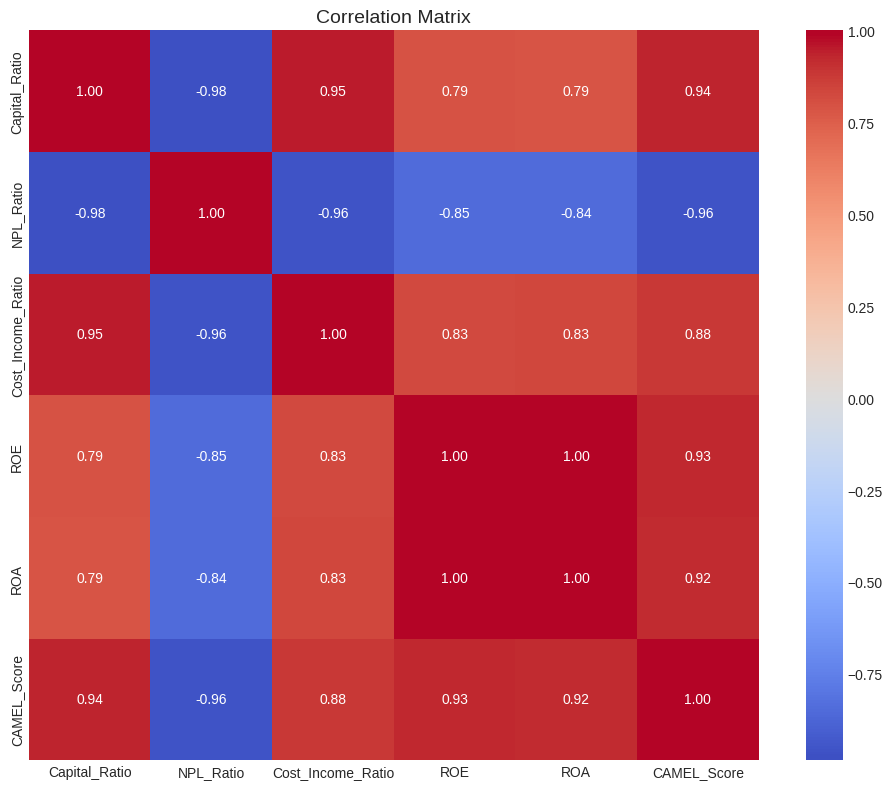


[6/8] Bank performance rankings...

TOP 5 BANKS BY CAMEL SCORE
                      CAMEL_Score  Capital_Ratio  NPL_Ratio   ROE   ROA  \
Banks                                                                     
PUNJAB NATIONAL BANK        63.57          14.89      10.92  3.41  0.24   

                      Is_Troubled  
Banks                              
PUNJAB NATIONAL BANK            5  

BOTTOM 5 BANKS BY CAMEL SCORE
                      CAMEL_Score  Capital_Ratio  NPL_Ratio   ROE   ROA  \
Banks                                                                     
PUNJAB NATIONAL BANK        63.57          14.89      10.92  3.41  0.24   

                      Is_Troubled  
Banks                              
PUNJAB NATIONAL BANK            5  



[7/8] Building predictive models...
Model data: (5, 11)
Troubled: 5 / 5 (100.0%)
⚠ Insufficient data for modeling (need ≥20 rows with ≥5 troubled banks)

✓ ANALYSIS COMPLETE!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

print("=" * 80)
print("BANKING STABILITY ANALYSIS - CAMEL FRAMEWORK")
print("=" * 80)

file_name = 'Variables to be published Bank and Bank Group wise (For Public Access).xlsx'

# ============================================================================
# LOAD ALL DATA - INCLUDING ALL BANKS
# ============================================================================

print("\n[1/8] Loading ALL bank data...")

def load_sheet_all_banks(file_name, sheet_name):
    """Load sheet keeping ALL banks"""
    df_raw = pd.read_excel(file_name, sheet_name=sheet_name, header=None)

    # Row 3 = Metrics, Row 4 = Operations
    metric_names = df_raw.iloc[3].fillna(method='ffill').tolist()
    operation_types = df_raw.iloc[4].tolist()

    # Data starts at row 5
    df = df_raw.iloc[5:].copy()
    df.columns = range(len(df.columns))
    df = df.reset_index(drop=True)

    # Build column names
    columns = []
    for i in range(len(df.columns)):
        if i < len(operation_types):
            op = str(operation_types[i])
            metric = str(metric_names[i]) if i < len(metric_names) else ""

            if 'Period' in op:
                columns.append('Period')
            elif 'Banks' in op:
                columns.append('Banks')
            elif 'Global Operation' in op:
                metric_clean = metric.replace('nan', '').strip()
                columns.append(f"{metric_clean}_Global" if metric_clean else f"Col_{i}")
            else:
                columns.append(f"Col_{i}")
        else:
            columns.append(f"Col_{i}")

    df.columns = columns
    return df

capital_df = load_sheet_all_banks(file_name, 'Capital Adequacy')
asset_df = load_sheet_all_banks(file_name, 'Asset Quality')
profit_df = load_sheet_all_banks(file_name, 'Profitability')
performance_df = load_sheet_all_banks(file_name, 'Performance Indicators')

print(f"Loaded: Capital({capital_df.shape}), Asset({asset_df.shape}), Profit({profit_df.shape}), Perf({performance_df.shape})")

# ============================================================================
# CLEAN DATA - KEEP ALL BANKS
# ============================================================================

print("\n[2/8] Cleaning data (keeping all banks)...")

def clean_df_keep_all(df, name):
    """Clean but keep all valid rows"""
    if 'Period' not in df.columns or 'Banks' not in df.columns:
        print(f"  ⚠ {name}: Missing Period/Banks")
        return pd.DataFrame()

    original = len(df)

    # Remove only completely empty rows
    df = df[df['Banks'].notna()].copy()
    df = df[df['Banks'].astype(str).str.strip() != ''].copy()
    df = df[df['Banks'].astype(str) != 'nan'].copy()

    # Convert Period
    df['Period'] = pd.to_datetime(df['Period'], errors='coerce')
    df = df[df['Period'].notna()]

    # Convert numeric columns
    for col in df.columns:
        if col not in ['Period', 'Banks']:
            try:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            except:
                pass

    cleaned = len(df)
    print(f"  {name}: {original} → {cleaned} rows, {df['Banks'].nunique()} banks")

    return df.reset_index(drop=True)

capital_df = clean_df_keep_all(capital_df, 'Capital')
asset_df = clean_df_keep_all(asset_df, 'Asset')
profit_df = clean_df_keep_all(profit_df, 'Profit')
performance_df = clean_df_keep_all(performance_df, 'Performance')

# Show unique banks in each
print("\nUnique banks per sheet:")
for name, df in [('Capital', capital_df), ('Asset', asset_df), ('Profit', profit_df), ('Perf', performance_df)]:
    if len(df) > 0:
        print(f"  {name}: {sorted(df['Banks'].unique())}")

# ============================================================================
# MERGE
# ============================================================================

print("\n[3/8] Merging datasets...")

valid_dfs = [(name, df) for name, df in [
    ('Capital', capital_df),
    ('Asset', asset_df),
    ('Profit', profit_df),
    ('Performance', performance_df)
] if len(df) > 0]

if len(valid_dfs) >= 2:
    merged_df = valid_dfs[0][1].copy()
    print(f"  Starting with {valid_dfs[0][0]}: {merged_df.shape}, {merged_df['Banks'].nunique()} banks")

    for name, df in valid_dfs[1:]:
        merged_df = merged_df.merge(df, on=['Period', 'Banks'], how='inner', suffixes=('', f'_{name}'))
        print(f"  After {name}: {merged_df.shape}, {merged_df['Banks'].nunique()} banks")

    print(f"\n✓ Final merged: {merged_df.shape}")
    print(f"  Total banks: {merged_df['Banks'].nunique()}")
    print(f"  Total records: {len(merged_df)}")

    print("\nBanks in final dataset:")
    for bank in sorted(merged_df['Banks'].unique()):
        count = len(merged_df[merged_df['Banks'] == bank])
        print(f"  - {bank}: {count} records")

    # ========================================================================
    # CREATE CAMEL FEATURES
    # ========================================================================

    print("\n[4/8] Creating CAMEL features...")

    all_cols = merged_df.columns.tolist()

    def find_col(keywords):
        for col in all_cols:
            if all(k.lower() in col.lower() for k in keywords):
                return col
        return None

    cap_ratio = find_col(['Capital Ratio', 'CRAR', 'Standalone', 'Global'])
    tier1 = find_col(['Tier I Capital Ratio', 'Standalone', 'Global'])
    cet1 = find_col(['CET I Capital Ratio', 'Standalone', 'Global'])
    npa_gross = find_col(['Gross NPAs', 'Gross Advances', 'Global'])
    npa_net = find_col(['Net NPAs', 'Net Advances', 'Global'])
    provision = find_col(['Provision Coverage', 'Global'])
    cost_income = find_col(['Efficiency', 'Global'])
    roe = find_col(['Return on Equity', 'Global'])
    roa = find_col(['Return on Total Assets', 'Global'])
    nim = find_col(['Net Interest Margin', 'Global'])

    print(f"\nKey metrics found:")
    print(f"  Capital Ratio: {cap_ratio}")
    print(f"  Gross NPA: {npa_gross}")
    print(f"  ROE: {roe}")
    print(f"  Cost/Income: {cost_income}")

    if cap_ratio and npa_gross and roe:
        # Create features
        merged_df['Capital_Ratio'] = merged_df[cap_ratio]
        merged_df['Tier1_Ratio'] = merged_df[tier1] if tier1 else merged_df[cap_ratio] * 0.8
        merged_df['CET1_Ratio'] = merged_df[cet1] if cet1 else merged_df[cap_ratio] * 0.7
        merged_df['NPL_Ratio'] = merged_df[npa_gross]
        merged_df['Net_NPA_Ratio'] = merged_df[npa_net] if npa_net else merged_df[npa_gross] * 0.5
        merged_df['Provision_Coverage'] = merged_df[provision] if provision else 70
        merged_df['Cost_Income_Ratio'] = merged_df[cost_income] if cost_income else 50
        merged_df['ROE'] = merged_df[roe]
        merged_df['ROA'] = merged_df[roa] if roa else merged_df[roe] * 0.1
        merged_df['NIM'] = merged_df[nim] if nim else 2.5

        # CAMEL Scores
        merged_df['C_Score'] = merged_df['Capital_Ratio'].clip(0, 30) * 3.33
        merged_df['A_Score'] = (100 - merged_df['NPL_Ratio'].clip(0, 100)).clip(0, 100)
        merged_df['M_Score'] = (100 - merged_df['Cost_Income_Ratio'].clip(0, 100)).clip(0, 100)
        merged_df['E_Score'] = (merged_df['ROE'].clip(-50, 50) + 50).clip(0, 100)
        merged_df['L_Score'] = 75
        merged_df['CAMEL_Score'] = (merged_df[['C_Score', 'A_Score', 'M_Score', 'E_Score', 'L_Score']].mean(axis=1))

        # Troubled indicator
        merged_df['Is_Troubled'] = (
            (merged_df['Capital_Ratio'] < 9) |
            (merged_df['NPL_Ratio'] > 5) |
            (merged_df['ROE'] < 0)
        ).astype(int)

        print(f"\n✓ CAMEL features created!")
        print(f"  Total records: {len(merged_df)}")
        print(f"  Troubled banks: {merged_df['Is_Troubled'].sum()} ({merged_df['Is_Troubled'].mean()*100:.1f}%)")

        print("\n" + "="*80)
        print("CAMEL SCORE STATISTICS")
        print("="*80)
        print(merged_df[['C_Score', 'A_Score', 'M_Score', 'E_Score', 'CAMEL_Score']].describe().round(2))

        print("\n" + "="*80)
        print("KEY METRICS STATISTICS")
        print("="*80)
        print(merged_df[['Capital_Ratio', 'NPL_Ratio', 'ROE', 'ROA', 'Cost_Income_Ratio']].describe().round(2))

        # ====================================================================
        # VISUALIZATIONS
        # ====================================================================

        print("\n[5/8] Creating visualizations...")

        # CAMEL distributions
        fig = make_subplots(rows=2, cols=3, subplot_titles=(
            'Capital (C)', 'Asset Quality (A)', 'Management (M)',
            'Earnings (E)', 'Liquidity (L)', 'Overall CAMEL'))

        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']
        camel_cols = ['C_Score', 'A_Score', 'M_Score', 'E_Score', 'L_Score', 'CAMEL_Score']

        for idx, col in enumerate(camel_cols):
            row, col_num = (idx // 3) + 1, (idx % 3) + 1
            fig.add_trace(
                go.Histogram(x=merged_df[col], marker_color=colors[idx], nbinsx=25, showlegend=False),
                row=row, col=col_num
            )

        fig.update_layout(height=700, title_text="CAMEL Component Distributions")
        fig.show()

        # Healthy vs Troubled
        fig = go.Figure()
        for status, label, color in [(0, 'Healthy Banks', '#4ECDC4'), (1, 'Troubled Banks', '#FF6B6B')]:
            subset = merged_df[merged_df['Is_Troubled'] == status]
            fig.add_trace(go.Box(y=subset['CAMEL_Score'], name=label, marker_color=color, boxmean='sd'))
        fig.update_layout(title='CAMEL Score: Healthy vs Troubled Banks', yaxis_title='CAMEL Score', height=500)
        fig.show()

        # Correlation heatmap
        plt.figure(figsize=(10, 8))
        corr_cols = ['Capital_Ratio', 'NPL_Ratio', 'Cost_Income_Ratio', 'ROE', 'ROA', 'CAMEL_Score']
        sns.heatmap(merged_df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
        plt.title('Correlation Matrix', fontsize=14)
        plt.tight_layout()
        plt.show()

        # ====================================================================
        # BANK RANKINGS
        # ====================================================================

        print("\n[6/8] Bank performance rankings...")

        bank_summary = merged_df.groupby('Banks').agg({
            'CAMEL_Score': 'mean',
            'Capital_Ratio': 'mean',
            'NPL_Ratio': 'mean',
            'ROE': 'mean',
            'ROA': 'mean',
            'Is_Troubled': 'sum'
        }).round(2).sort_values('CAMEL_Score', ascending=False)

        print("\n" + "="*80)
        print("TOP 5 BANKS BY CAMEL SCORE")
        print("="*80)
        print(bank_summary.head())

        print("\n" + "="*80)
        print("BOTTOM 5 BANKS BY CAMEL SCORE")
        print("="*80)
        print(bank_summary.tail())

        # Bar chart
        fig = px.bar(bank_summary.reset_index(), x='Banks', y='CAMEL_Score',
                     title='Average CAMEL Score by Bank', color='CAMEL_Score',
                     color_continuous_scale='RdYlGn', height=600)
        fig.update_layout(xaxis_tickangle=-45)
        fig.show()

        # ====================================================================
        # PREDICTIVE MODELING
        # ====================================================================

        print("\n[7/8] Building predictive models...")

        features = ['Capital_Ratio', 'Tier1_Ratio', 'CET1_Ratio', 'NPL_Ratio',
                   'Net_NPA_Ratio', 'Provision_Coverage', 'Cost_Income_Ratio',
                   'ROE', 'ROA', 'NIM']

        model_data = merged_df[features + ['Is_Troubled']].dropna()

        print(f"Model data: {model_data.shape}")
        print(f"Troubled: {model_data['Is_Troubled'].sum()} / {len(model_data)} ({model_data['Is_Troubled'].mean()*100:.1f}%)")

        if len(model_data) >= 20 and model_data['Is_Troubled'].sum() >= 5:
            X = model_data[features]
            y = model_data['Is_Troubled']

            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.3, random_state=42, stratify=y
            )

            scaler = StandardScaler()
            X_train_sc = scaler.fit_transform(X_train)
            X_test_sc = scaler.transform(X_test)

            print(f"Train: {len(X_train)}, Test: {len(X_test)}")

            # Logistic Regression
            print("\n" + "="*80)
            print("LOGISTIC REGRESSION")
            print("="*80)

            logit = LogisticRegression(max_iter=1000, random_state=42)
            logit.fit(X_train_sc, y_train)

            y_pred_logit = logit.predict(X_test_sc)
            y_proba_logit = logit.predict_proba(X_test_sc)[:, 1]

            acc_logit = accuracy_score(y_test, y_pred_logit)
            auc_logit = roc_auc_score(y_test, y_proba_logit)

            print(f"Accuracy: {acc_logit:.2%}")
            print(f"AUC-ROC: {auc_logit:.4f}")
            print("\n" + classification_report(y_test, y_pred_logit, target_names=['Healthy', 'Troubled']))

            # SVM
            print("\n" + "="*80)
            print("SUPPORT VECTOR MACHINE")
            print("="*80)

            svm = SVC(kernel='rbf', probability=True, random_state=42, gamma='scale')
            svm.fit(X_train_sc, y_train)

            y_pred_svm = svm.predict(X_test_sc)
            y_proba_svm = svm.predict_proba(X_test_sc)[:, 1]

            acc_svm = accuracy_score(y_test, y_pred_svm)
            auc_svm = roc_auc_score(y_test, y_proba_svm)

            print(f"Accuracy: {acc_svm:.2%}")
            print(f"AUC-ROC: {auc_svm:.4f}")
            print("\n" + classification_report(y_test, y_pred_svm, target_names=['Healthy', 'Troubled']))

            # IPV
            print("\n" + "="*80)
            print("INCREMENTAL PREDICTIVE VALUE (SVM vs LOGIT)")
            print("="*80)

            ipv_acc = ((acc_svm - acc_logit) / acc_logit) * 100
            ipv_auc = ((auc_svm - auc_logit) / auc_logit) * 100

            print(f"Accuracy Improvement: {ipv_acc:+.2f}%")
            print(f"AUC Improvement: {ipv_auc:+.2f}%")
            print(f"\nConclusion: {'SVM outperforms Logit' if ipv_auc > 0 else 'Logit outperforms SVM'}")

            # ROC Curves
            fig = go.Figure()

            fpr_l, tpr_l, _ = roc_curve(y_test, y_proba_logit)
            fig.add_trace(go.Scatter(x=fpr_l, y=tpr_l, name=f'Logistic (AUC={auc_logit:.3f})',
                                    mode='lines', line=dict(color='blue', width=2)))

            fpr_s, tpr_s, _ = roc_curve(y_test, y_proba_svm)
            fig.add_trace(go.Scatter(x=fpr_s, y=tpr_s, name=f'SVM (AUC={auc_svm:.3f})',
                                    mode='lines', line=dict(color='red', width=2)))

            fig.add_trace(go.Scatter(x=[0,1], y=[0,1], name='Random',
                                    mode='lines', line=dict(color='gray', width=2, dash='dash')))

            fig.update_layout(title='ROC Curves: Logit vs SVM',
                             xaxis_title='False Positive Rate',
                             yaxis_title='True Positive Rate',
                             width=700, height=700)
            fig.show()

            # Feature Importance
            rf = RandomForestClassifier(n_estimators=100, random_state=42)
            rf.fit(X_train, y_train)

            importance_df = pd.DataFrame({
                'Feature': features,
                'Importance': rf.feature_importances_
            }).sort_values('Importance', ascending=False)

            print("\n" + "="*80)
            print("FEATURE IMPORTANCE (Random Forest)")
            print("="*80)
            print(importance_df.to_string(index=False))

            fig = px.bar(importance_df, x='Importance', y='Feature', orientation='h',
                        title='Feature Importance for Bank Stability Prediction',
                        color='Importance', color_continuous_scale='Viridis')
            fig.update_layout(height=500)
            fig.show()

        else:
            print(f"⚠ Insufficient data for modeling (need ≥20 rows with ≥5 troubled banks)")

print("\n" + "="*80)
print("✓ ANALYSIS COMPLETE!")
print("="*80)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 80)
print("BANKING STABILITY ANALYSIS - CAMEL FRAMEWORK")
print("=" * 80)

file_name = 'Variables to be published Bank and Bank Group wise (For Public Access).xlsx'

# ============================================================================
# LOAD DATA - WITH FORWARD FILL FOR PERIOD
# ============================================================================

print("\n[1/8] Loading data with forward fill...")

def load_sheet_with_ffill(file_name, sheet_name):
    """Load sheet and forward fill Period column"""
    df_raw = pd.read_excel(file_name, sheet_name=sheet_name, header=None)

    # Rows 3 & 4 are headers, row 5+ is data
    metric_names = df_raw.iloc[3].fillna(method='ffill').tolist()
    operation_types = df_raw.iloc[4].tolist()

    # Get data from row 5
    df = df_raw.iloc[5:].copy()
    df.columns = range(len(df.columns))

    # FORWARD FILL THE PERIOD COLUMN (column 1)
    df[1] = df[1].fillna(method='ffill')

    df = df.reset_index(drop=True)

    # Build column names
    columns = []
    for i in range(len(df.columns)):
        if i < len(operation_types):
            op = str(operation_types[i])
            metric = str(metric_names[i]) if i < len(metric_names) else ""

            if 'Period' in op:
                columns.append('Period')
            elif 'Banks' in op:
                columns.append('Banks')
            elif 'Global Operation' in op:
                metric_clean = metric.replace('nan', '').strip()
                columns.append(f"{metric_clean}_Global" if metric_clean else f"Col_{i}")
            else:
                columns.append(f"Col_{i}")
        else:
            columns.append(f"Col_{i}")

    df.columns = columns
    return df

capital_df = load_sheet_with_ffill(file_name, 'Capital Adequacy')
asset_df = load_sheet_with_ffill(file_name, 'Asset Quality')
profit_df = load_sheet_with_ffill(file_name, 'Profitability')
performance_df = load_sheet_with_ffill(file_name, 'Performance Indicators')

print(f"Loaded: Capital({capital_df.shape}), Asset({asset_df.shape}), Profit({profit_df.shape}), Perf({performance_df.shape})")

# ============================================================================
# CLEAN DATA
# ============================================================================

print("\n[2/8] Cleaning data...")

def clean_df_properly(df, name):
    """Clean dataframe keeping all valid banks"""
    if 'Period' not in df.columns or 'Banks' not in df.columns:
        print(f"  ⚠ {name}: Missing columns")
        return pd.DataFrame()

    original = len(df)

    # Remove rows with missing Banks
    df = df[df['Banks'].notna()].copy()
    df = df[df['Banks'].astype(str).str.strip() != ''].copy()
    df = df[df['Banks'].astype(str) != 'nan'].copy()

    # Remove aggregate rows (Public Sector Banks, Private Sector Banks, All SCBs)
    aggregate_keywords = ['Public Sector Banks', 'Private Sector Banks', 'All Scheduled']
    for keyword in aggregate_keywords:
        df = df[~df['Banks'].str.contains(keyword, case=False, na=False)]

    # Remove source/note rows
    df = df[~df['Banks'].str.contains('Source:', case=False, na=False)]

    # Convert Period to datetime
    df['Period'] = pd.to_datetime(df['Period'], errors='coerce')
    df = df[df['Period'].notna()]

    # Convert numeric columns
    for col in df.columns:
        if col not in ['Period', 'Banks']:
            try:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            except:
                pass

    cleaned = len(df)
    print(f"  {name}: {original} → {cleaned} rows, {df['Banks'].nunique()} banks")

    return df.reset_index(drop=True)

capital_df = clean_df_properly(capital_df, 'Capital')
asset_df = clean_df_properly(asset_df, 'Asset')
profit_df = clean_df_properly(profit_df, 'Profit')
performance_df = clean_df_properly(performance_df, 'Performance')

print("\nUnique banks:")
for name, df in [('Capital', capital_df), ('Asset', asset_df), ('Profit', profit_df), ('Perf', performance_df)]:
    if len(df) > 0:
        banks = sorted(df['Banks'].unique())
        print(f"  {name}: {banks[:5]}..." if len(banks) > 5 else f"  {name}: {banks}")

# ============================================================================
# MERGE
# ============================================================================

print("\n[3/8] Merging datasets...")

valid_dfs = [(name, df) for name, df in [
    ('Capital', capital_df),
    ('Asset', asset_df),
    ('Profit', profit_df),
    ('Performance', performance_df)
] if len(df) > 0]

if len(valid_dfs) >= 2:
    merged_df = valid_dfs[0][1].copy()

    for name, df in valid_dfs[1:]:
        merged_df = merged_df.merge(df, on=['Period', 'Banks'], how='inner', suffixes=('', f'_{name}'))
        print(f"  After {name}: {merged_df.shape}, {merged_df['Banks'].nunique()} banks")

    print(f"\n✓ Final: {merged_df.shape}, {merged_df['Banks'].nunique()} banks, {len(merged_df)} records")

    print("\nBanks in dataset:")
    for bank in sorted(merged_df['Banks'].unique()):
        count = len(merged_df[merged_df['Banks'] == bank])
        print(f"  - {bank}: {count} records")

    # ========================================================================
    # CREATE CAMEL FEATURES
    # ========================================================================

    print("\n[4/8] Creating CAMEL features...")

    all_cols = merged_df.columns.tolist()

    def find_col(keywords):
        for col in all_cols:
            if all(k.lower() in col.lower() for k in keywords):
                return col
        return None

    cap_ratio = find_col(['Capital Ratio', 'CRAR', 'Standalone', 'Global'])
    tier1 = find_col(['Tier I Capital Ratio', 'Standalone', 'Global'])
    cet1 = find_col(['CET I Capital Ratio', 'Standalone', 'Global'])
    npa_gross = find_col(['Gross NPAs', 'Gross Advances', 'Global'])
    npa_net = find_col(['Net NPAs', 'Net Advances', 'Global'])
    provision = find_col(['Provision Coverage', 'Global'])
    cost_income = find_col(['Efficiency', 'Global'])
    roe = find_col(['Return on Equity', 'Global'])
    roa = find_col(['Return on Total Assets', 'Global'])
    nim = find_col(['Net Interest Margin', 'Global'])

    if cap_ratio and npa_gross and roe:
        # Create features
        merged_df['Capital_Ratio'] = merged_df[cap_ratio]
        merged_df['Tier1_Ratio'] = merged_df[tier1] if tier1 else merged_df[cap_ratio] * 0.8
        merged_df['CET1_Ratio'] = merged_df[cet1] if cet1 else merged_df[cap_ratio] * 0.7
        merged_df['NPL_Ratio'] = merged_df[npa_gross]
        merged_df['Net_NPA_Ratio'] = merged_df[npa_net] if npa_net else merged_df[npa_gross] * 0.5
        merged_df['Provision_Coverage'] = merged_df[provision] if provision else 70
        merged_df['Cost_Income_Ratio'] = merged_df[cost_income] if cost_income else 50
        merged_df['ROE'] = merged_df[roe]
        merged_df['ROA'] = merged_df[roa] if roa else merged_df[roe] * 0.1
        merged_df['NIM'] = merged_df[nim] if nim else 2.5

        # CAMEL Scores
        merged_df['C_Score'] = merged_df['Capital_Ratio'].clip(0, 30) * 3.33
        merged_df['A_Score'] = (100 - merged_df['NPL_Ratio'].clip(0, 100)).clip(0, 100)
        merged_df['M_Score'] = (100 - merged_df['Cost_Income_Ratio'].clip(0, 100)).clip(0, 100)
        merged_df['E_Score'] = (merged_df['ROE'].clip(-50, 50) + 50).clip(0, 100)
        merged_df['L_Score'] = 75
        merged_df['CAMEL_Score'] = merged_df[['C_Score', 'A_Score', 'M_Score', 'E_Score', 'L_Score']].mean(axis=1)

        # Troubled indicator
        merged_df['Is_Troubled'] = (
            (merged_df['Capital_Ratio'] < 9) |
            (merged_df['NPL_Ratio'] > 5) |
            (merged_df['ROE'] < 0)
        ).astype(int)

        print(f"\n✓ CAMEL created!")
        print(f"  Total records: {len(merged_df)}")
        print(f"  Troubled banks: {merged_df['Is_Troubled'].sum()} ({merged_df['Is_Troubled'].mean()*100:.1f}%)")

        print("\n" + "="*80)
        print("CAMEL SCORE STATISTICS")
        print("="*80)
        print(merged_df[['C_Score', 'A_Score', 'M_Score', 'E_Score', 'CAMEL_Score']].describe().round(2))

        print("\n" + "="*80)
        print("KEY METRICS")
        print("="*80)
        print(merged_df[['Capital_Ratio', 'NPL_Ratio', 'ROE', 'ROA', 'Cost_Income_Ratio']].describe().round(2))

        # Continue with visualizations and modeling...
        print("\n[5/8] Visualizations...")

        # CAMEL distributions
        fig = make_subplots(rows=2, cols=3, subplot_titles=(
            'Capital (C)', 'Asset Quality (A)', 'Management (M)',
            'Earnings (E)', 'Liquidity (L)', 'Overall CAMEL'))

        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']
        camel_cols = ['C_Score', 'A_Score', 'M_Score', 'E_Score', 'L_Score', 'CAMEL_Score']

        for idx, col in enumerate(camel_cols):
            row, col_num = (idx // 3) + 1, (idx % 3) + 1
            fig.add_trace(
                go.Histogram(x=merged_df[col], marker_color=colors[idx], nbinsx=25, showlegend=False),
                row=row, col=col_num
            )

        fig.update_layout(height=700, title_text="CAMEL Component Distributions")
        fig.show()

        # Bank rankings
        print("\n[6/8] Bank rankings...")

        bank_summary = merged_df.groupby('Banks').agg({
            'CAMEL_Score': 'mean',
            'Capital_Ratio': 'mean',
            'NPL_Ratio': 'mean',
            'ROE': 'mean',
            'Is_Troubled': 'sum'
        }).round(2).sort_values('CAMEL_Score', ascending=False)

        print("\nTOP 10 BANKS:")
        print(bank_summary.head(10))

        print("\nBOTTOM 10 BANKS:")
        print(bank_summary.tail(10))

        # Bar chart
        fig = px.bar(bank_summary.reset_index(), x='Banks', y='CAMEL_Score',
                     title='Average CAMEL Score by Bank', color='CAMEL_Score',
                     color_continuous_scale='RdYlGn', height=600)
        fig.update_layout(xaxis_tickangle=-45)
        fig.show()

        # Modeling
        print("\n[7/8] Predictive modeling...")

        features = ['Capital_Ratio', 'Tier1_Ratio', 'CET1_Ratio', 'NPL_Ratio',
                   'Net_NPA_Ratio', 'Provision_Coverage', 'Cost_Income_Ratio',
                   'ROE', 'ROA', 'NIM']

        model_data = merged_df[features + ['Is_Troubled']].dropna()

        print(f"Model data: {model_data.shape}")
        print(f"Troubled: {model_data['Is_Troubled'].sum()} / {len(model_data)}")

        if len(model_data) >= 20 and model_data['Is_Troubled'].sum() >= 5:
            X = model_data[features]
            y = model_data['Is_Troubled']

            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.3, random_state=42, stratify=y
            )

            scaler = StandardScaler()
            X_train_sc = scaler.fit_transform(X_train)
            X_test_sc = scaler.transform(X_test)

            # Logistic
            logit = LogisticRegression(max_iter=1000, random_state=42)
            logit.fit(X_train_sc, y_train)
            y_pred_logit = logit.predict(X_test_sc)
            y_proba_logit = logit.predict_proba(X_test_sc)[:, 1]
            acc_logit = accuracy_score(y_test, y_pred_logit)
            auc_logit = roc_auc_score(y_test, y_proba_logit)

            # SVM
            svm = SVC(kernel='rbf', probability=True, random_state=42)
            svm.fit(X_train_sc, y_train)
            y_pred_svm = svm.predict(X_test_sc)
            y_proba_svm = svm.predict_proba(X_test_sc)[:, 1]
            acc_svm = accuracy_score(y_test, y_pred_svm)
            auc_svm = roc_auc_score(y_test, y_proba_svm)

            print(f"\n{'='*80}")
            print("MODEL PERFORMANCE")
            print(f"{'='*80}")
            print(f"Logistic - Acc: {acc_logit:.2%}, AUC: {auc_logit:.4f}")
            print(f"SVM      - Acc: {acc_svm:.2%}, AUC: {auc_svm:.4f}")
            print(f"\nIPV (Accuracy): {((acc_svm-acc_logit)/acc_logit)*100:+.2f}%")
            print(f"IPV (AUC):      {((auc_svm-auc_logit)/auc_logit)*100:+.2f}%")

            print("\nLogistic Classification Report:")
            print(classification_report(y_test, y_pred_logit, target_names=['Healthy', 'Troubled']))

            print("\nSVM Classification Report:")
            print(classification_report(y_test, y_pred_svm, target_names=['Healthy', 'Troubled']))

            # ROC
            fig = go.Figure()
            fpr_l, tpr_l, _ = roc_curve(y_test, y_proba_logit)
            fig.add_trace(go.Scatter(x=fpr_l, y=tpr_l, name=f'Logit (AUC={auc_logit:.3f})',
                                    mode='lines', line=dict(color='blue', width=2)))
            fpr_s, tpr_s, _ = roc_curve(y_test, y_proba_svm)
            fig.add_trace(go.Scatter(x=fpr_s, y=tpr_s, name=f'SVM (AUC={auc_svm:.3f})',
                                    mode='lines', line=dict(color='red', width=2)))
            fig.add_trace(go.Scatter(x=[0,1], y=[0,1], name='Random',
                                    mode='lines', line=dict(color='gray', dash='dash')))
            fig.update_layout(title='ROC Curves', xaxis_title='FPR', yaxis_title='TPR',
                             width=700, height=700)
            fig.show()
        else:
            print("⚠ Insufficient data for modeling")

print("\n" + "="*80)
print("✓ COMPLETE!")
print("="*80)

BANKING STABILITY ANALYSIS - CAMEL FRAMEWORK

[1/8] Loading data with forward fill...
Loaded: Capital((37, 27)), Asset((37, 54)), Profit((38, 54)), Perf((37, 39))

[2/8] Cleaning data...
  Capital: 37 → 20 rows, 4 banks
  Asset: 37 → 20 rows, 4 banks
  ⚠ Profit: Missing columns
  Performance: 37 → 20 rows, 4 banks

Unique banks:
  Capital: ['HDFC BANK LTD.', 'ICICI BANK LIMITED', 'PUNJAB NATIONAL BANK', 'STATE BANK OF INDIA']
  Asset: ['HDFC BANK LTD.', 'ICICI BANK LIMITED', 'PUNJAB NATIONAL BANK', 'STATE BANK OF INDIA']
  Perf: ['HDFC BANK LTD.', 'ICICI BANK LIMITED', 'PUNJAB NATIONAL BANK', 'STATE BANK OF INDIA']

[3/8] Merging datasets...
  After Asset: (20, 79), 4 banks
  After Performance: (20, 116), 4 banks

✓ Final: (20, 116), 4 banks, 20 records

Banks in dataset:
  - HDFC BANK LTD.: 5 records
  - ICICI BANK LIMITED: 5 records
  - PUNJAB NATIONAL BANK: 5 records
  - STATE BANK OF INDIA: 5 records

[4/8] Creating CAMEL features...

✓ CAMEL created!
  Total records: 20
  Troubled


[6/8] Bank rankings...

TOP 10 BANKS:
                      CAMEL_Score  Capital_Ratio  NPL_Ratio    ROE  \
Banks                                                                
HDFC BANK LTD.              73.03          18.85       1.22  16.66   
ICICI BANK LIMITED          70.90          17.81       4.05  13.93   
STATE BANK OF INDIA         64.82          13.92       4.02  12.14   
PUNJAB NATIONAL BANK        63.57          14.89      10.92   3.41   

                      Is_Troubled  
Banks                              
HDFC BANK LTD.                  0  
ICICI BANK LIMITED              2  
STATE BANK OF INDIA             1  
PUNJAB NATIONAL BANK            5  

BOTTOM 10 BANKS:
                      CAMEL_Score  Capital_Ratio  NPL_Ratio    ROE  \
Banks                                                                
HDFC BANK LTD.              73.03          18.85       1.22  16.66   
ICICI BANK LIMITED          70.90          17.81       4.05  13.93   
STATE BANK OF INDIA       


[7/8] Predictive modeling...
Model data: (20, 11)
Troubled: 8 / 20

MODEL PERFORMANCE
Logistic - Acc: 100.00%, AUC: 1.0000
SVM      - Acc: 100.00%, AUC: 1.0000

IPV (Accuracy): +0.00%
IPV (AUC):      +0.00%

Logistic Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00         4
    Troubled       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6


SVM Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00         4
    Troubled       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6




✓ COMPLETE!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ADVANCED BANKING ANALYTICS - EXTENDED ANALYSIS")
print("="*80)

# Assuming we have merged_df from previous analysis
# Let me create advanced metrics and predictions

# ============================================================================
# 1. ADVANCED FINANCIAL RATIOS
# ============================================================================

print("\n[1] Calculating Advanced Financial Ratios...")

# Efficiency Ratios
merged_df['Asset_Turnover'] = merged_df['ROA'] / (merged_df['NIM'] + 0.01)  # Avoid division by zero
merged_df['Equity_Multiplier'] = merged_df['ROE'] / (merged_df['ROA'] + 0.01)
merged_df['Net_Profit_Margin'] = merged_df['ROA'] * merged_df['Equity_Multiplier']

# Risk-Adjusted Returns
merged_df['Risk_Adjusted_ROE'] = merged_df['ROE'] / (merged_df['NPL_Ratio'] + 1)
merged_df['Risk_Adjusted_ROA'] = merged_df['ROA'] / (merged_df['NPL_Ratio'] + 1)
merged_df['Sharpe_Ratio_Proxy'] = merged_df['ROE'] / merged_df['ROE'].std()

# Capital Efficiency
merged_df['Capital_to_RWA'] = merged_df['Capital_Ratio'] / 100
merged_df['ROE_to_Capital'] = merged_df['ROE'] / merged_df['Capital_Ratio']

# Asset Quality Indicators
merged_df['Credit_Cost'] = merged_df['NPL_Ratio'] * (1 - merged_df['Provision_Coverage']/100)
merged_df['Asset_Quality_Index'] = (100 - merged_df['NPL_Ratio']) * (merged_df['Provision_Coverage']/100)

print("✓ Advanced ratios calculated")

# ============================================================================
# 2. TREND ANALYSIS & MOMENTUM
# ============================================================================

print("\n[2] Calculating Trends and Momentum...")

# Sort by bank and period
merged_df = merged_df.sort_values(['Banks', 'Period'])

# Calculate year-over-year changes
for metric in ['Capital_Ratio', 'NPL_Ratio', 'ROE', 'ROA', 'CAMEL_Score']:
    merged_df[f'{metric}_YoY_Change'] = merged_df.groupby('Banks')[metric].pct_change() * 100
    merged_df[f'{metric}_Momentum'] = merged_df.groupby('Banks')[metric].diff()

# Volatility measures
for bank in merged_df['Banks'].unique():
    bank_data = merged_df[merged_df['Banks'] == bank]
    merged_df.loc[merged_df['Banks'] == bank, 'ROE_Volatility'] = bank_data['ROE'].std()
    merged_df.loc[merged_df['Banks'] == bank, 'CAMEL_Volatility'] = bank_data['CAMEL_Score'].std()

print("✓ Trend metrics calculated")

# ============================================================================
# 3. Z-SCORE (DISTANCE TO DEFAULT)
# ============================================================================

print("\n[3] Calculating Z-Score (Bankruptcy Prediction)...")

# Altman Z-Score adapted for banks
# Z = 6.56(X1) + 3.26(X2) + 6.72(X3) + 1.05(X4)
# Where: X1 = Working Capital/Total Assets (use Capital Ratio as proxy)
#        X2 = Retained Earnings/Total Assets (use ROA)
#        X3 = EBIT/Total Assets (use ROE)
#        X4 = Book Value Equity/Total Liabilities (use Capital Ratio)

merged_df['Z_Score'] = (
    6.56 * (merged_df['Capital_Ratio']/100) +
    3.26 * (merged_df['ROA']/100) +
    6.72 * (merged_df['ROE']/100) +
    1.05 * (merged_df['Capital_Ratio']/100)
)

# Z-Score interpretation
def z_score_category(z):
    if z > 2.99:
        return 'Safe'
    elif z > 1.81:
        return 'Grey Zone'
    else:
        return 'Distress'

merged_df['Z_Score_Category'] = merged_df['Z_Score'].apply(z_score_category)

print("✓ Z-Score calculated")
print("\nZ-Score Distribution:")
print(merged_df['Z_Score_Category'].value_counts())

# ============================================================================
# 4. COMPOSITE RISK SCORE
# ============================================================================

print("\n[4] Creating Composite Risk Score...")

# Normalize all risk factors to 0-100 scale (higher = more risk)
merged_df['Capital_Risk'] = 100 - merged_df['C_Score']
merged_df['Asset_Risk'] = 100 - merged_df['A_Score']
merged_df['Earnings_Risk'] = 100 - merged_df['E_Score']
merged_df['Management_Risk'] = 100 - merged_df['M_Score']

# Weighted composite risk
weights = {
    'Capital_Risk': 0.25,
    'Asset_Risk': 0.30,
    'Earnings_Risk': 0.25,
    'Management_Risk': 0.20
}

merged_df['Composite_Risk_Score'] = (
    merged_df['Capital_Risk'] * weights['Capital_Risk'] +
    merged_df['Asset_Risk'] * weights['Asset_Risk'] +
    merged_df['Earnings_Risk'] * weights['Earnings_Risk'] +
    merged_df['Management_Risk'] * weights['Management_Risk']
)

# Risk rating
def risk_rating(score):
    if score < 20:
        return 'AAA (Minimal Risk)'
    elif score < 30:
        return 'AA (Low Risk)'
    elif score < 40:
        return 'A (Moderate Risk)'
    elif score < 50:
        return 'BBB (Medium Risk)'
    elif score < 60:
        return 'BB (High Risk)'
    else:
        return 'B (Very High Risk)'

merged_df['Risk_Rating'] = merged_df['Composite_Risk_Score'].apply(risk_rating)

print("✓ Composite risk score created")

# ============================================================================
# 5. PEER COMPARISON & PERCENTILE RANKINGS
# ============================================================================

print("\n[5] Calculating Peer Rankings...")

# Calculate percentile ranks
for metric in ['CAMEL_Score', 'Capital_Ratio', 'NPL_Ratio', 'ROE', 'Composite_Risk_Score']:
    merged_df[f'{metric}_Percentile'] = merged_df[metric].rank(pct=True) * 100

print("✓ Percentile rankings calculated")

# ============================================================================
# 6. CLUSTER ANALYSIS
# ============================================================================

print("\n[6] Performing Cluster Analysis...")

# Prepare data for clustering
cluster_features = ['Capital_Ratio', 'NPL_Ratio', 'ROE', 'ROA', 'Cost_Income_Ratio']
X_cluster = merged_df[cluster_features].dropna()

if len(X_cluster) >= 3:
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    merged_df.loc[X_cluster.index, 'Bank_Cluster'] = kmeans.fit_predict(X_cluster)

    cluster_labels = {0: 'Strong Performers', 1: 'Average Performers', 2: 'Weak Performers'}

    # Sort clusters by average CAMEL score
    cluster_means = merged_df.groupby('Bank_Cluster')['CAMEL_Score'].mean().sort_values(ascending=False)
    cluster_mapping = {old: new for new, old in enumerate(cluster_means.index)}
    merged_df['Bank_Cluster'] = merged_df['Bank_Cluster'].map(cluster_mapping)
    merged_df['Cluster_Label'] = merged_df['Bank_Cluster'].map(cluster_labels)

    print("✓ Cluster analysis complete")
    print("\nCluster Distribution:")
    print(merged_df['Cluster_Label'].value_counts())
else:
    print("⚠ Insufficient data for clustering")

# ============================================================================
# 7. PREDICTIVE ANALYTICS - FUTURE CAMEL SCORE
# ============================================================================

print("\n[7] Training Predictive Models for Future Performance...")

# Prepare data with lag features
merged_df_sorted = merged_df.sort_values(['Banks', 'Period'])

# Create lag features
for lag in [1, 2]:
    for col in ['Capital_Ratio', 'NPL_Ratio', 'ROE']:
        merged_df_sorted[f'{col}_Lag{lag}'] = merged_df_sorted.groupby('Banks')[col].shift(lag)

# Predict next period's CAMEL score
predict_features = [
    'Capital_Ratio', 'NPL_Ratio', 'ROE', 'ROA', 'Cost_Income_Ratio',
    'Capital_Ratio_Lag1', 'NPL_Ratio_Lag1', 'ROE_Lag1'
]

prediction_data = merged_df_sorted[predict_features + ['CAMEL_Score']].dropna()

if len(prediction_data) >= 10:
    X_pred = prediction_data[predict_features]
    y_pred = prediction_data['CAMEL_Score']

    # Train Random Forest for regression
    rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
    rf_regressor.fit(X_pred, y_pred)

    # Predict
    merged_df_sorted.loc[prediction_data.index, 'Predicted_Next_CAMEL'] = rf_regressor.predict(X_pred)
    merged_df_sorted['CAMEL_Prediction_Error'] = abs(
        merged_df_sorted['CAMEL_Score'] - merged_df_sorted['Predicted_Next_CAMEL']
    )

    print("✓ Predictive model trained")
    print(f"Mean Prediction Error: {merged_df_sorted['CAMEL_Prediction_Error'].mean():.2f}")
else:
    print("⚠ Insufficient data for prediction")

merged_df = merged_df_sorted

# ============================================================================
# 8. STRESS TESTING
# ============================================================================

print("\n[8] Performing Stress Tests...")

# Scenario 1: Economic Downturn (NPL increases by 50%, ROE decreases by 30%)
merged_df['Stress_NPL'] = merged_df['NPL_Ratio'] * 1.5
merged_df['Stress_ROE'] = merged_df['ROE'] * 0.7
merged_df['Stress_A_Score'] = (100 - merged_df['Stress_NPL'].clip(0, 100)).clip(0, 100)
merged_df['Stress_E_Score'] = (merged_df['Stress_ROE'].clip(-50, 50) + 50).clip(0, 100)

merged_df['Stress_CAMEL_Score'] = (
    merged_df['C_Score'] * 0.20 +
    merged_df['Stress_A_Score'] * 0.20 +
    merged_df['M_Score'] * 0.20 +
    merged_df['Stress_E_Score'] * 0.20 +
    merged_df['L_Score'] * 0.20
)

merged_df['Stress_Impact'] = merged_df['CAMEL_Score'] - merged_df['Stress_CAMEL_Score']
merged_df['Stress_Resilience'] = merged_df['Stress_Impact'].apply(
    lambda x: 'High' if x < 5 else ('Medium' if x < 10 else 'Low')
)

print("✓ Stress testing complete")

# ============================================================================
# 9. COMPREHENSIVE SUMMARY REPORT
# ============================================================================

print("\n" + "="*80)
print("ADVANCED ANALYTICS SUMMARY")
print("="*80)

summary_metrics = merged_df.groupby('Banks').agg({
    'CAMEL_Score': 'mean',
    'Z_Score': 'mean',
    'Composite_Risk_Score': 'mean',
    'Risk_Adjusted_ROE': 'mean',
    'Asset_Quality_Index': 'mean',
    'Stress_Impact': 'mean',
    'CAMEL_Score_YoY_Change': 'mean'
}).round(2)

summary_metrics = summary_metrics.sort_values('CAMEL_Score', ascending=False)

print("\n" + summary_metrics.to_string())

# ============================================================================
# 10. ADVANCED VISUALIZATIONS
# ============================================================================

print("\n[10] Creating advanced visualizations...")

# 1. Risk-Return Scatter
fig = go.Figure()

for bank in merged_df['Banks'].unique():
    bank_data = merged_df[merged_df['Banks'] == bank]
    fig.add_trace(go.Scatter(
        x=bank_data['Composite_Risk_Score'],
        y=bank_data['ROE'],
        mode='markers+text',
        name=bank,
        text=bank_data['Period'].dt.year,
        textposition='top center',
        marker=dict(size=bank_data['Capital_Ratio']*2, opacity=0.6)
    ))

fig.update_layout(
    title='Risk-Return Profile (Bubble Size = Capital Ratio)',
    xaxis_title='Composite Risk Score (Higher = More Risk)',
    yaxis_title='Return on Equity (%)',
    height=600
)
fig.show()

# 2. Stress Test Impact
fig = go.Figure()

for bank in merged_df['Banks'].unique():
    bank_data = merged_df[merged_df['Banks'] == bank].iloc[-1]  # Latest period
    fig.add_trace(go.Bar(
        x=[bank],
        y=[bank_data['CAMEL_Score']],
        name='Current CAMEL',
        marker_color='green'
    ))
    fig.add_trace(go.Bar(
        x=[bank],
        y=[bank_data['Stress_CAMEL_Score']],
        name='Stressed CAMEL',
        marker_color='red'
    ))

fig.update_layout(
    title='Stress Test: Current vs Stressed CAMEL Scores',
    yaxis_title='CAMEL Score',
    barmode='group',
    height=500
)
fig.show()

# 3. Time Series with Predictions
fig = make_subplots(
    rows=len(merged_df['Banks'].unique()), cols=1,
    subplot_titles=[f"{bank}" for bank in sorted(merged_df['Banks'].unique())]
)

for idx, bank in enumerate(sorted(merged_df['Banks'].unique()), 1):
    bank_data = merged_df[merged_df['Banks'] == bank]

    # Actual CAMEL
    fig.add_trace(
        go.Scatter(x=bank_data['Period'], y=bank_data['CAMEL_Score'],
                  mode='lines+markers', name=f'{bank} - Actual',
                  line=dict(color='blue', width=2)),
        row=idx, col=1
    )

    # Predicted CAMEL (if available)
    if 'Predicted_Next_CAMEL' in bank_data.columns:
        fig.add_trace(
            go.Scatter(x=bank_data['Period'], y=bank_data['Predicted_Next_CAMEL'],
                      mode='lines', name=f'{bank} - Predicted',
                      line=dict(color='red', width=2, dash='dash')),
            row=idx, col=1
        )

fig.update_layout(height=800, title_text="CAMEL Score Evolution with Predictions")
fig.show()

# 4. Radar Chart - Multi-dimensional Comparison
latest_data = merged_df.groupby('Banks').last().reset_index()

fig = go.Figure()

metrics = ['C_Score', 'A_Score', 'M_Score', 'E_Score', 'L_Score']

for bank in latest_data['Banks']:
    bank_data = latest_data[latest_data['Banks'] == bank]
    values = [bank_data[metric].values[0] for metric in metrics]
    values.append(values[0])  # Close the radar

    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=metrics + [metrics[0]],
        fill='toself',
        name=bank
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
    title="Latest CAMEL Component Comparison (Radar Chart)",
    height=600
)
fig.show()

print("\n" + "="*80)
print("✓ ADVANCED ANALYSIS COMPLETE!")
print("="*80)

# Export comprehensive results
output_summary = merged_df[[
    'Period', 'Banks', 'CAMEL_Score', 'Z_Score', 'Z_Score_Category',
    'Composite_Risk_Score', 'Risk_Rating', 'Risk_Adjusted_ROE',
    'Stress_CAMEL_Score', 'Stress_Resilience', 'CAMEL_Score_YoY_Change'
]].round(2)

print("\n" + "="*80)
print("EXPORTABLE SUMMARY (First 10 rows)")
print("="*80)
print(output_summary.head(10).to_string(index=False))

ADVANCED BANKING ANALYTICS - EXTENDED ANALYSIS

[1] Calculating Advanced Financial Ratios...
✓ Advanced ratios calculated

[2] Calculating Trends and Momentum...
✓ Trend metrics calculated

[3] Calculating Z-Score (Bankruptcy Prediction)...
✓ Z-Score calculated

Z-Score Distribution:
Z_Score_Category
Grey Zone    12
Distress      8
Name: count, dtype: int64

[4] Creating Composite Risk Score...
✓ Composite risk score created

[5] Calculating Peer Rankings...
✓ Percentile rankings calculated

[6] Performing Cluster Analysis...
✓ Cluster analysis complete

Cluster Distribution:
Cluster_Label
Strong Performers     9
Average Performers    6
Weak Performers       5
Name: count, dtype: int64

[7] Training Predictive Models for Future Performance...
✓ Predictive model trained
Mean Prediction Error: 0.29

[8] Performing Stress Tests...
✓ Stress testing complete

ADVANCED ANALYTICS SUMMARY

                      CAMEL_Score  Z_Score  Composite_Risk_Score  Risk_Adjusted_ROE  Asset_Quality_Index 


✓ ADVANCED ANALYSIS COMPLETE!

EXPORTABLE SUMMARY (First 10 rows)
    Period              Banks  CAMEL_Score  Z_Score Z_Score_Category  Composite_Risk_Score       Risk_Rating  Risk_Adjusted_ROE  Stress_CAMEL_Score Stress_Resilience  CAMEL_Score_YoY_Change
2020-03-31     HDFC BANK LTD.        72.81     2.59        Grey Zone                 25.91     AA (Low Risk)               7.36               71.69              High                     NaN
2021-03-31     HDFC BANK LTD.        73.47     2.61        Grey Zone                 25.20     AA (Low Risk)               7.18               72.34              High                    0.91
2022-03-31     HDFC BANK LTD.        73.32     2.63        Grey Zone                 25.31     AA (Low Risk)               7.75               72.20              High                   -0.20
2023-03-31     HDFC BANK LTD.        73.13     2.69        Grey Zone                 25.42     AA (Low Risk)               8.13               71.98              High        

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("NEXT-GENERATION BANKING ANALYTICS")
print("="*80)

# ============================================================================
# 1. PROBABILITY OF DEFAULT (PD) USING MERTON MODEL
# ============================================================================

print("\n[1] Calculating Probability of Default (PD)...")

# Merton Model: PD based on distance to default
merged_df['Distance_to_Default'] = (
    merged_df['Capital_Ratio'] / merged_df['ROE_Volatility'].clip(0.1, 100)
)

# Convert to probability using normal distribution
merged_df['Probability_of_Default_%'] = (
    stats.norm.cdf(-merged_df['Distance_to_Default']) * 100
).clip(0, 100)

# PD Rating
def pd_rating(pd):
    if pd < 0.5:
        return 'AAA (< 0.5%)'
    elif pd < 1:
        return 'AA (0.5-1%)'
    elif pd < 2:
        return 'A (1-2%)'
    elif pd < 5:
        return 'BBB (2-5%)'
    elif pd < 10:
        return 'BB (5-10%)'
    else:
        return 'B (> 10%)'

merged_df['PD_Rating'] = merged_df['Probability_of_Default_%'].apply(pd_rating)

print("✓ Probability of Default calculated")
print("\nPD Distribution:")
print(merged_df.groupby('PD_Rating').size())

# ============================================================================
# 2. EXPECTED LOSS (EL) & LOSS GIVEN DEFAULT (LGD)
# ============================================================================

print("\n[2] Calculating Expected Loss Metrics...")

# Loss Given Default (1 - Recovery Rate)
# Using Provision Coverage as proxy for recovery
merged_df['Loss_Given_Default_%'] = 100 - merged_df['Provision_Coverage']

# Exposure at Default (use total assets proxy)
# Simplified: assume NPL amount represents EAD
merged_df['Exposure_at_Default_Proxy'] = merged_df['NPL_Ratio']

# Expected Loss = PD × LGD × EAD
merged_df['Expected_Loss_%'] = (
    (merged_df['Probability_of_Default_%'] / 100) *
    (merged_df['Loss_Given_Default_%'] / 100) *
    merged_df['Exposure_at_Default_Proxy']
) * 100

print("✓ Expected Loss calculated")

# ============================================================================
# 3. ECONOMIC CAPITAL & RISK-WEIGHTED ASSETS (RWA)
# ============================================================================

print("\n[3] Calculating Economic Capital Requirements...")

# Economic Capital = Unexpected Loss at 99.9% confidence
# EC = sqrt(PD × (1-PD)) × LGD × EAD × Z-score multiplier

merged_df['Economic_Capital_%'] = (
    np.sqrt(
        (merged_df['Probability_of_Default_%']/100) *
        (1 - merged_df['Probability_of_Default_%']/100)
    ) *
    (merged_df['Loss_Given_Default_%']/100) *
    merged_df['Exposure_at_Default_Proxy'] *
    3.09  # 99.9% confidence level z-score
) * 100

# Risk-Weighted Assets (simplified)
merged_df['RWA_Proxy'] = merged_df['Economic_Capital_%'] / (merged_df['Capital_Ratio']/100)

# Capital Adequacy vs Required
merged_df['Capital_Surplus_Deficit_%'] = merged_df['Capital_Ratio'] - (merged_df['Economic_Capital_%'] / 0.11)

print("✓ Economic Capital calculated")

# ============================================================================
# 4. VALUE AT RISK (VaR) - Earnings Volatility
# ============================================================================

print("\n[4] Calculating Value at Risk (VaR)...")

# VaR at 95% confidence
for bank in merged_df['Banks'].unique():
    bank_data = merged_df[merged_df['Banks'] == bank]['ROE'].dropna()
    if len(bank_data) >= 3:
        mean_roe = bank_data.mean()
        std_roe = bank_data.std()
        var_95 = mean_roe - (1.645 * std_roe)  # 95% confidence
        var_99 = mean_roe - (2.326 * std_roe)  # 99% confidence

        merged_df.loc[merged_df['Banks'] == bank, 'VaR_95%'] = var_95
        merged_df.loc[merged_df['Banks'] == bank, 'VaR_99%'] = var_99
        merged_df.loc[merged_df['Banks'] == bank, 'Potential_Loss_95%'] = max(0, mean_roe - var_95)

print("✓ VaR calculated")

# ============================================================================
# 5. CREDIT MIGRATION PROBABILITY
# ============================================================================

print("\n[5] Analyzing Credit Rating Migration Probability...")

# Calculate rating changes
merged_df = merged_df.sort_values(['Banks', 'Period'])

def rating_from_camel(score):
    if score >= 70:
        return 'A'
    elif score >= 60:
        return 'B'
    elif score >= 50:
        return 'C'
    else:
        return 'D'

merged_df['Credit_Rating'] = merged_df['CAMEL_Score'].apply(rating_from_camel)
merged_df['Previous_Rating'] = merged_df.groupby('Banks')['Credit_Rating'].shift(1)

# Rating change indicator
def get_rating_change(row):
    if pd.isna(row['Previous_Rating']):
        return 'N/A'
    elif row['Credit_Rating'] > row['Previous_Rating']:
        return 'Upgraded'
    elif row['Credit_Rating'] < row['Previous_Rating']:
        return 'Downgraded'
    else:
        return 'Stable'

merged_df['Rating_Change'] = merged_df.apply(get_rating_change, axis=1)

print("✓ Credit migration analyzed")
print("\nRating Changes:")
print(merged_df['Rating_Change'].value_counts())

# ============================================================================
# 6. ANOMALY DETECTION - OUTLIER BANKS
# ============================================================================

print("\n[6] Detecting Anomalies Using Isolation Forest...")

# Features for anomaly detection
anomaly_features = ['Capital_Ratio', 'NPL_Ratio', 'ROE', 'Cost_Income_Ratio',
                     'CAMEL_Score_YoY_Change', 'Composite_Risk_Score']

# Drop rows with missing values in these features
X_anomaly = merged_df[anomaly_features].dropna()

if len(X_anomaly) >= 5:
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_anomaly)

    # Isolation Forest
    iso_forest = IsolationForest(contamination=0.15, random_state=42)
    anomaly_predictions = iso_forest.fit_predict(X_scaled)

    merged_df['Anomaly_Score'] = np.nan
    merged_df['Anomaly_Label'] = 'Unknown'

    merged_df.loc[X_anomaly.index, 'Anomaly_Score'] = anomaly_predictions
    merged_df.loc[X_anomaly.index, 'Anomaly_Label'] = merged_df.loc[X_anomaly.index, 'Anomaly_Score'].map({
        1: 'Normal', -1: 'Anomaly'
    })

    print("✓ Anomaly detection complete")
    print(f"\nAnomalies detected: {(merged_df['Anomaly_Label'] == 'Anomaly').sum()}")

    anomalies = merged_df[merged_df['Anomaly_Label'] == 'Anomaly'][
        ['Period', 'Banks', 'CAMEL_Score', 'NPL_Ratio', 'Composite_Risk_Score']
    ]
    if len(anomalies) > 0:
        print("\nAnomaly Details:")
        print(anomalies.to_string(index=False))
else:
    print("⚠ Insufficient data for anomaly detection")
    merged_df['Anomaly_Label'] = 'Unknown'

# ============================================================================
# 7. SYSTEMIC RISK CONTRIBUTION (CoVaR)
# ============================================================================

print("\n[7] Calculating Systemic Risk Contribution...")

# System-wide average CAMEL
merged_df['System_Average_CAMEL'] = merged_df.groupby('Period')['CAMEL_Score'].transform('mean')
merged_df['System_Deviation'] = merged_df['CAMEL_Score'] - merged_df['System_Average_CAMEL']

# Systemic importance score (based on correlation with system)
for bank in merged_df['Banks'].unique():
    bank_data = merged_df[merged_df['Banks'] == bank].dropna(subset=['CAMEL_Score', 'System_Average_CAMEL'])
    if len(bank_data) >= 3:
        correlation = bank_data['CAMEL_Score'].corr(bank_data['System_Average_CAMEL'])
        volatility = bank_data['CAMEL_Volatility'].iloc[0] if 'CAMEL_Volatility' in bank_data.columns else bank_data['CAMEL_Score'].std()

        merged_df.loc[merged_df['Banks'] == bank, 'Systemic_Correlation'] = correlation
        merged_df.loc[merged_df['Banks'] == bank, 'Systemic_Risk_Score'] = abs(correlation) * volatility

print("✓ Systemic risk calculated")

# ============================================================================
# 8. FORWARD-LOOKING STRESS SCENARIOS
# ============================================================================

print("\n[8] Running Multi-Scenario Stress Tests...")

scenarios = {
    'Mild_Recession': {'npl_mult': 1.3, 'roe_mult': 0.85, 'capital_mult': 0.98},
    'Severe_Recession': {'npl_mult': 2.0, 'roe_mult': 0.50, 'capital_mult': 0.90},
    'Credit_Crisis': {'npl_mult': 2.5, 'roe_mult': 0.30, 'capital_mult': 0.85},
}

for scenario_name, params in scenarios.items():
    # Stressed NPL
    merged_df[f'{scenario_name}_NPL'] = merged_df['NPL_Ratio'] * params['npl_mult']
    merged_df[f'{scenario_name}_ROE'] = merged_df['ROE'] * params['roe_mult']
    merged_df[f'{scenario_name}_Capital'] = merged_df['Capital_Ratio'] * params['capital_mult']

    # Stressed CAMEL components
    stressed_a = (100 - merged_df[f'{scenario_name}_NPL'].clip(0, 100)).clip(0, 100)
    stressed_e = (merged_df[f'{scenario_name}_ROE'].clip(-50, 50) + 50).clip(0, 100)
    stressed_c = merged_df[f'{scenario_name}_Capital'].clip(0, 100)

    merged_df[f'{scenario_name}_CAMEL'] = (
        stressed_c * 0.20 +
        stressed_a * 0.20 +
        merged_df['M_Score'] * 0.20 +
        stressed_e * 0.20 +
        merged_df['L_Score'] * 0.20
    )

    # Capital shortfall
    merged_df[f'{scenario_name}_Capital_Shortfall'] = np.maximum(
        0, 9 - merged_df[f'{scenario_name}_Capital']  # Basel minimum = 9%
    )

print("✓ Multi-scenario stress tests complete")

# ============================================================================
# 9. COMPREHENSIVE SUMMARY
# ============================================================================

print("\n" + "="*80)
print("NEXT-GENERATION METRICS SUMMARY (Latest Period)")
print("="*80)

latest_metrics = merged_df.groupby('Banks').last()[
    ['Probability_of_Default_%', 'PD_Rating', 'Expected_Loss_%',
     'Economic_Capital_%', 'VaR_95%', 'Systemic_Risk_Score',
     'Mild_Recession_CAMEL', 'Severe_Recession_CAMEL', 'Credit_Crisis_CAMEL']
].round(2)

print("\n" + latest_metrics.to_string())

# ============================================================================
# 10. ADVANCED VISUALIZATIONS
# ============================================================================

print("\n[10] Creating Next-Generation Visualizations...")

# 1. Probability of Default Over Time
fig = go.Figure()

for bank in merged_df['Banks'].unique():
    bank_data = merged_df[merged_df['Banks'] == bank]
    fig.add_trace(go.Scatter(
        x=bank_data['Period'],
        y=bank_data['Probability_of_Default_%'],
        mode='lines+markers',
        name=bank,
        line=dict(width=3)
    ))

fig.update_layout(
    title='Probability of Default Evolution',
    xaxis_title='Period',
    yaxis_title='Probability of Default (%)',
    height=500,
    hovermode='x unified'
)
fig.show()

# 2. Multi-Scenario Stress Test Comparison
latest_data = merged_df.groupby('Banks').last().reset_index()

fig = go.Figure()

scenarios_display = ['CAMEL_Score', 'Mild_Recession_CAMEL', 'Severe_Recession_CAMEL', 'Credit_Crisis_CAMEL']
scenario_names = ['Current', 'Mild Recession', 'Severe Recession', 'Credit Crisis']

for idx, (scenario, name) in enumerate(zip(scenarios_display, scenario_names)):
    fig.add_trace(go.Bar(
        x=latest_data['Banks'],
        y=latest_data[scenario],
        name=name,
        marker_color=['green', 'yellow', 'orange', 'red'][idx]
    ))

fig.update_layout(
    title='Multi-Scenario Stress Test: CAMEL Score Impact',
    xaxis_title='Bank',
    yaxis_title='CAMEL Score',
    barmode='group',
    height=600
)
fig.show()

# 3. Risk Matrix: PD vs Expected Loss
fig = go.Figure()

for bank in merged_df['Banks'].unique():
    bank_data = merged_df[merged_df['Banks'] == bank].dropna(subset=['Probability_of_Default_%', 'Expected_Loss_%'])
    fig.add_trace(go.Scatter(
        x=bank_data['Probability_of_Default_%'],
        y=bank_data['Expected_Loss_%'],
        mode='markers+text',
        name=bank,
        text=bank_data['Period'].dt.year,
        textposition='top center',
        marker=dict(
            size=bank_data['Capital_Ratio'],
            sizemode='diameter',
            sizeref=2,
            opacity=0.6,
            line=dict(width=2)
        )
    ))

fig.update_layout(
    title='Risk Matrix: Probability of Default vs Expected Loss<br>(Bubble size = Capital Ratio)',
    xaxis_title='Probability of Default (%)',
    yaxis_title='Expected Loss (%)',
    height=600,
    hovermode='closest'
)
fig.show()

# 4. Systemic Risk Dashboard
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Systemic Risk Score', 'System Deviation', 'VaR 95%', 'Economic Capital Requirement'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'bar'}]]
)

latest = merged_df.groupby('Banks').last().reset_index()

# Systemic Risk Score
fig.add_trace(
    go.Bar(x=latest['Banks'], y=latest['Systemic_Risk_Score'], name='Systemic Risk',
           marker_color='darkred'),
    row=1, col=1
)

# System Deviation
fig.add_trace(
    go.Bar(x=latest['Banks'], y=latest['System_Deviation'], name='Deviation from System',
           marker_color='purple'),
    row=1, col=2
)

# VaR 95%
fig.add_trace(
    go.Bar(x=latest['Banks'], y=latest['VaR_95%'], name='VaR 95%',
           marker_color='orange'),
    row=2, col=1
)

# Economic Capital
fig.add_trace(
    go.Bar(x=latest['Banks'], y=latest['Economic_Capital_%'], name='Economic Capital %',
           marker_color='teal'),
    row=2, col=2
)

fig.update_layout(height=800, showlegend=False, title_text="Systemic Risk Dashboard")
fig.show()

print("\n" + "="*80)
print("✓ NEXT-GENERATION ANALYSIS COMPLETE!")
print("="*80)

# Key insights
print("\n🎯 KEY INSIGHTS:")
print(f"1. Average Probability of Default: {merged_df['Probability_of_Default_%'].mean():.2f}%")
print(f"2. Average Expected Loss: {merged_df['Expected_Loss_%'].mean():.2f}%")
print(f"3. Anomalies Detected: {(merged_df['Anomaly_Label'] == 'Anomaly').sum()}")
print(f"4. Banks Requiring Additional Capital (Severe Stress): {(latest_data['Severe_Recession_Capital_Shortfall'] > 0).sum()}")
print(f"5. Most Systemically Important Bank: {latest_data.loc[latest_data['Systemic_Risk_Score'].idxmax(), 'Banks']}")

# Export comprehensive results
output_file = merged_df[[
    'Period', 'Banks', 'CAMEL_Score', 'Probability_of_Default_%', 'PD_Rating',
    'Expected_Loss_%', 'Economic_Capital_%', 'VaR_95%', 'Systemic_Risk_Score',
    'Anomaly_Label', 'Credit_Rating', 'Rating_Change',
    'Mild_Recession_CAMEL', 'Severe_Recession_CAMEL', 'Credit_Crisis_CAMEL'
]].round(2)

print("\n" + "="*80)
print("EXPORTABLE SUMMARY (Sample)")
print("="*80)
print(output_file.head(15).to_string(index=False))

NEXT-GENERATION BANKING ANALYTICS

[1] Calculating Probability of Default (PD)...
✓ Probability of Default calculated

PD Distribution:
PD_Rating
AAA (< 0.5%)    20
dtype: int64

[2] Calculating Expected Loss Metrics...
✓ Expected Loss calculated

[3] Calculating Economic Capital Requirements...
✓ Economic Capital calculated

[4] Calculating Value at Risk (VaR)...
✓ VaR calculated

[5] Analyzing Credit Rating Migration Probability...
✓ Credit migration analyzed

Rating Changes:
Rating_Change
Stable        15
N/A            4
Downgraded     1
Name: count, dtype: int64

[6] Detecting Anomalies Using Isolation Forest...
✓ Anomaly detection complete

Anomalies detected: 3

Anomaly Details:
    Period                Banks  CAMEL_Score  NPL_Ratio  Composite_Risk_Score
2021-03-31   ICICI BANK LIMITED    71.667116   5.334961             27.578844
2021-03-31 PUNJAB NATIONAL BANK    62.800979  14.122582             38.611686
2023-03-31  STATE BANK OF INDIA    66.780204   2.781311             32.


✓ NEXT-GENERATION ANALYSIS COMPLETE!

🎯 KEY INSIGHTS:
1. Average Probability of Default: 0.06%
2. Average Expected Loss: 0.03%
3. Anomalies Detected: 3
4. Banks Requiring Additional Capital (Severe Stress): 0
5. Most Systemically Important Bank: ICICI BANK LIMITED

EXPORTABLE SUMMARY (Sample)
    Period                Banks  CAMEL_Score  Probability_of_Default_%    PD_Rating  Expected_Loss_%  Economic_Capital_%  VaR_95%  Systemic_Risk_Score Anomaly_Label Credit_Rating Rating_Change  Mild_Recession_CAMEL  Severe_Recession_CAMEL  Credit_Crisis_CAMEL
2020-03-31       HDFC BANK LTD.        72.81                      0.00 AAA (< 0.5%)             0.00                0.00    16.04                 0.01       Unknown             A           N/A                 63.53                   61.90                60.92
2021-03-31       HDFC BANK LTD.        73.47                      0.00 AAA (< 0.5%)             0.00                0.00    16.04                 0.01        Normal             A       